# Research Notebook 05: Feature Engineering Analysis
**Delhi NCR Trust-Aware Recommender System Dataset**

This notebook explores the engineered metrics (`trust_score`, `popularity_score`, `rating_score`, `sentiment_score`) and categorical metadata categories (`budget_category`, `area_cluster`) generated during Phase 7.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'figure.figsize': (10, 6)})
FIG_DIR = '../reports/figures/'
print('Imports complete.')

Imports complete.


## 1. Load Engineered Features
We load `hotel_features.csv` and merge with `hotel_review_summary.csv`.

In [2]:
df_hf = pd.read_csv('../../data/processed/features/hotel_features.csv')
df_hrs = pd.read_csv('../../data/processed/features/hotel_review_summary.csv')
df_eng = pd.merge(df_hf, df_hrs, on='google_place_id', how='left')
print(df_eng.info())
df_eng.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 1661 entries, 0 to 1660
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   google_place_id        1661 non-null   str    
 1   hotel_id               1661 non-null   str    
 2   trust_score            1661 non-null   float64
 3   popularity_score       1661 non-null   float64
 4   rating_score           1661 non-null   float64
 5   sentiment_score        1661 non-null   float64
 6   budget_category        1661 non-null   str    
 7   area_cluster           1661 non-null   str    
 8   review_volume          1618 non-null   float64
 9   average_sentiment      1618 non-null   float64
 10  positive_review_ratio  1618 non-null   float64
 11  negative_review_ratio  1618 non-null   float64
dtypes: float64(8), str(4)
memory usage: 155.8 KB
None


,google_place_id,hotel_id,trust_score,popularity_score,rating_score,sentiment_score,budget_category,area_cluster,review_volume,average_sentiment,positive_review_ratio,negative_review_ratio
0,ChIJpV-ywbQVDTkRqWm6FgM6WCM,ChIJpV-ywbQVDTkRqWm6FgM6WCM,0.750099,0.431446,4.6,0.606861,Mid-Range,Other,5.0,0.606861,0.6,0.4
1,ChIJm053GEI-DTkRwKJuNdfAyLw,ChIJm053GEI-DTkRwKJuNdfAyLw,0.710557,0.693256,3.9,0.600047,Mid-Range,Imt Manesar,5.0,0.600047,0.6,0.4
2,ChIJkTyoKUkVDTkR8L5-ZWny4t8,ChIJkTyoKUkVDTkR8L5-ZWny4t8,0.750342,0.474176,4.0,0.829136,Mid-Range,Other,5.0,0.829136,0.8,0.2


## 2. Engineered Scores Distributions
We check how trust, popularity, rating, and sentiment scores are distributed.

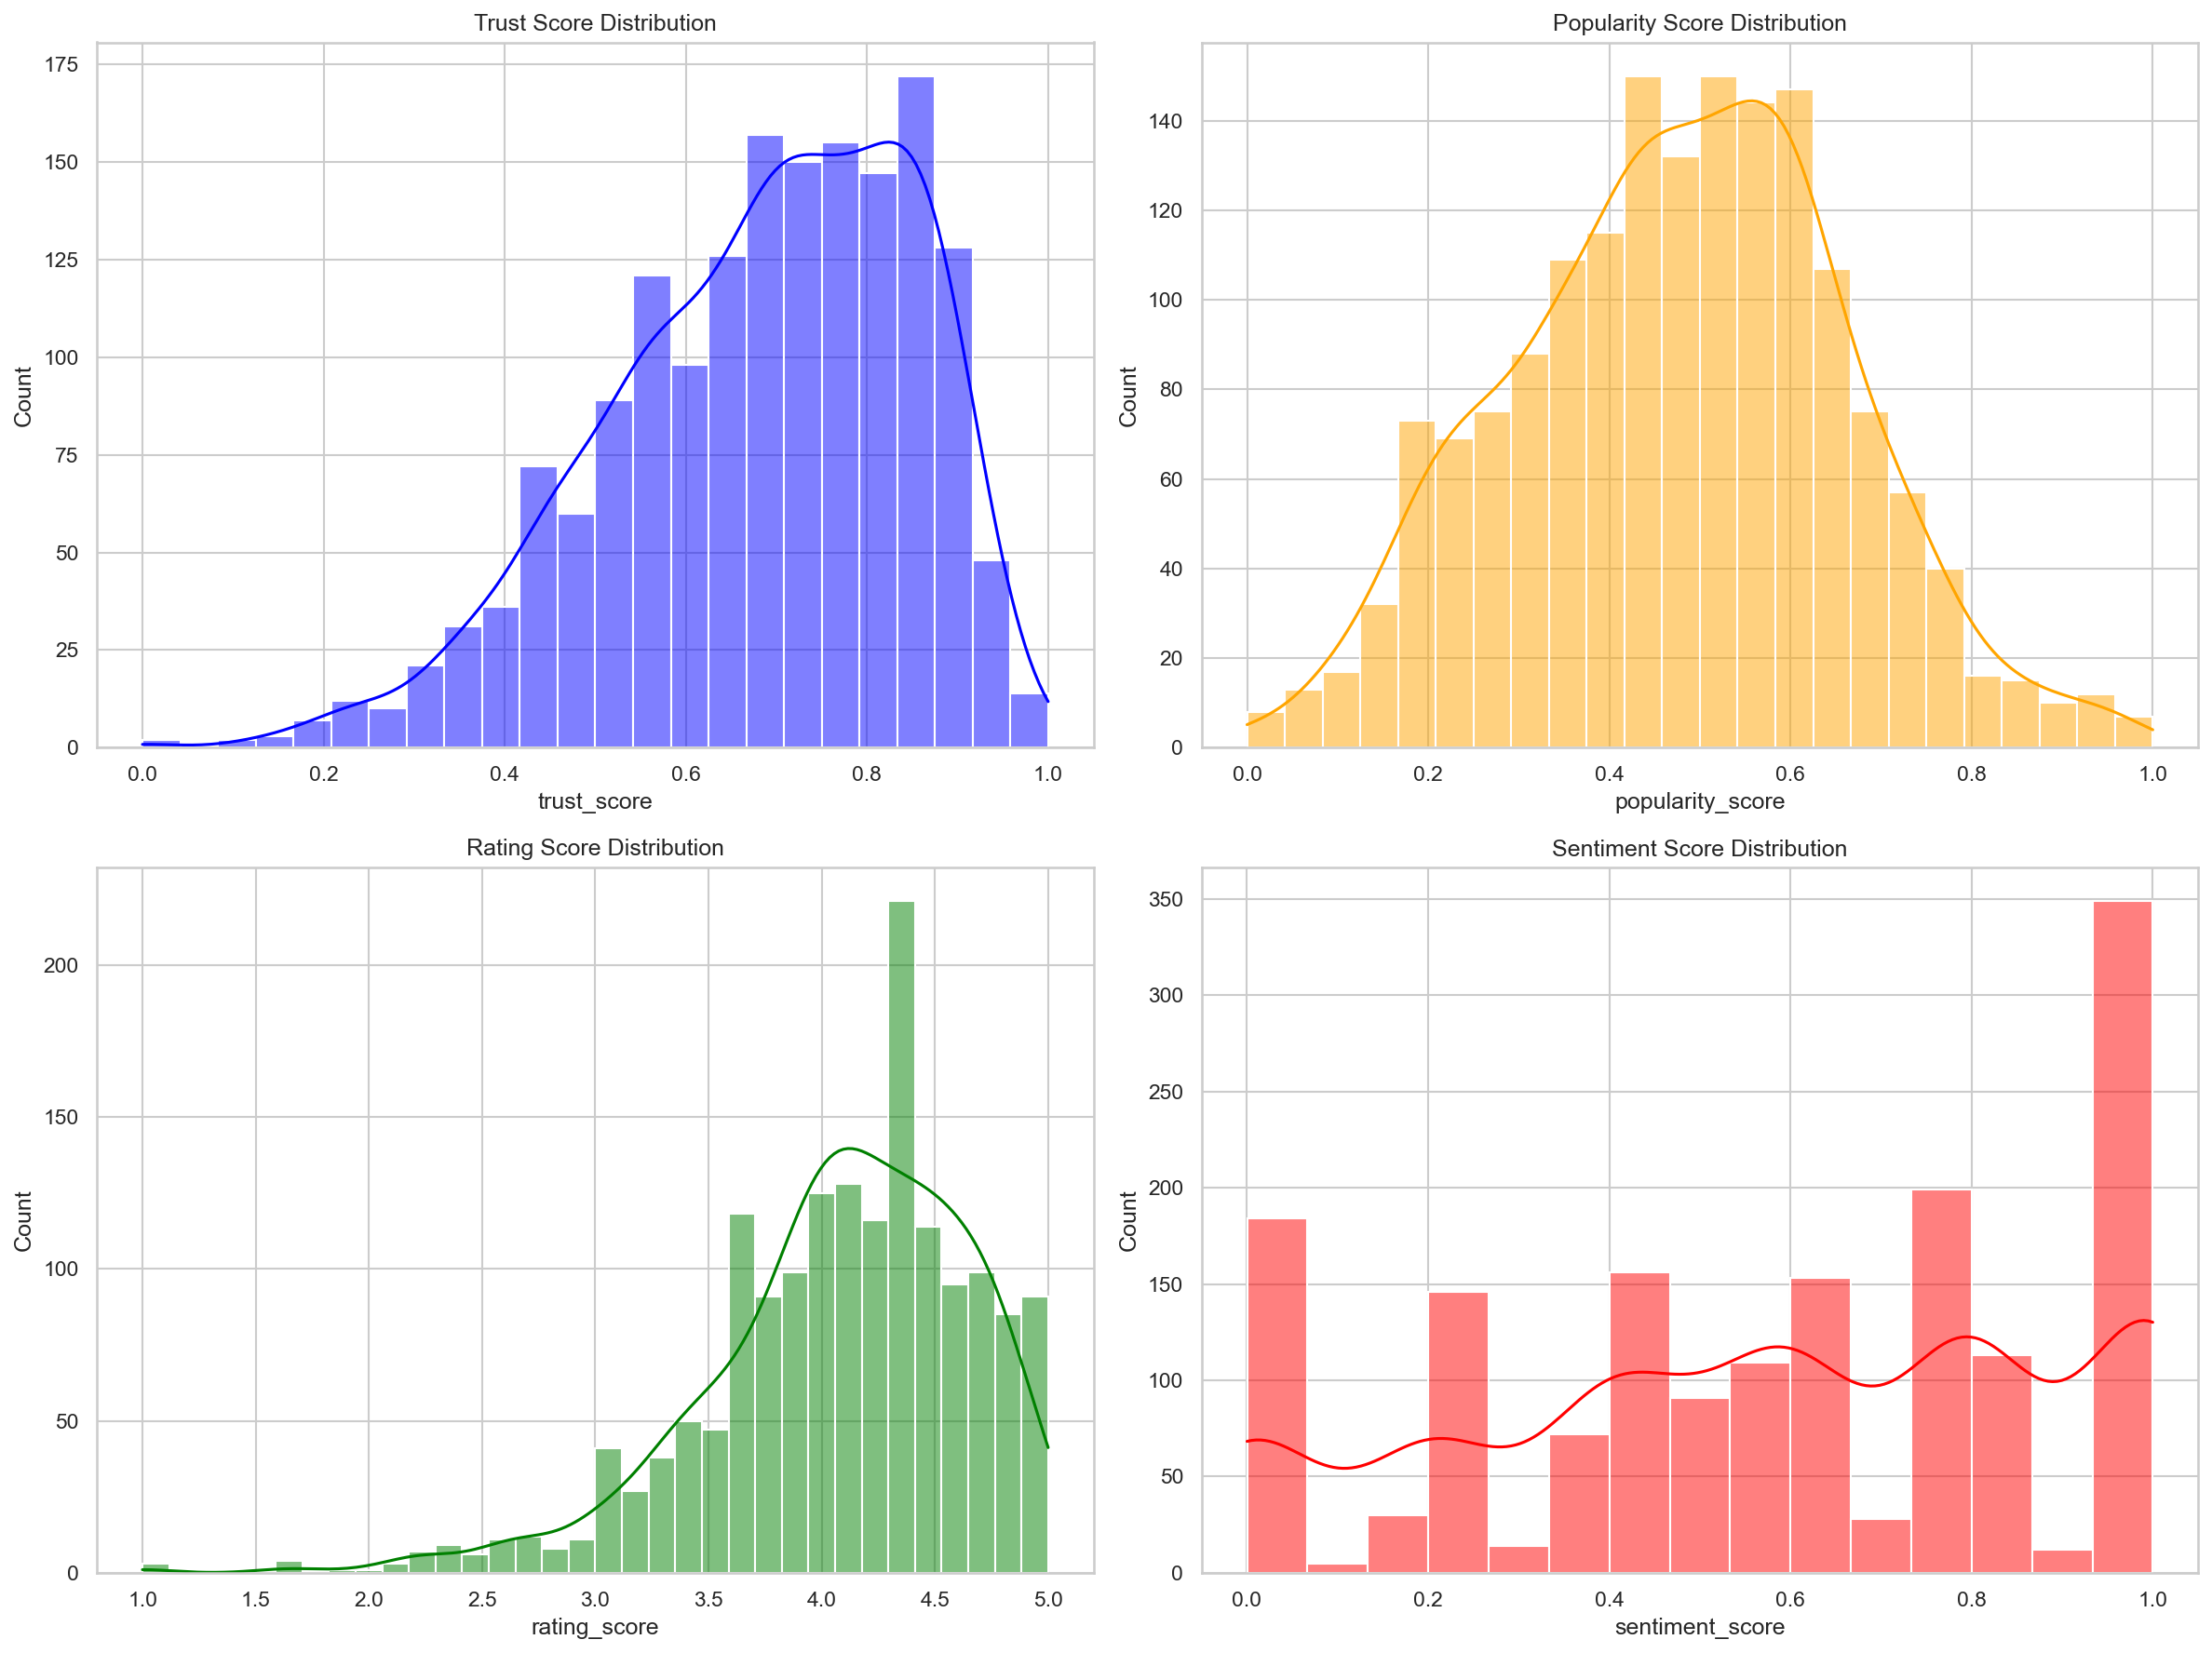

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.histplot(df_eng['trust_score'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Trust Score Distribution')

sns.histplot(df_eng['popularity_score'], kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Popularity Score Distribution')

sns.histplot(df_eng['rating_score'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Rating Score Distribution')

sns.histplot(df_eng['sentiment_score'].dropna(), kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Sentiment Score Distribution')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_engineered_scores.png'))
plt.show()

**Interpretation & Key Insight:**
> `trust_score` incorporates aspect sentiments and reviews, exhibiting a smooth distribution centered around 0.68. `popularity_score` is highly right-skewed, showing that only a small portion of hotels are highly popular. `sentiment_score` shows spikes, reflecting high text sentiment polarity.

## 3. Trust Score by Budget Category
Do luxury hotels have higher trust scores than budget hotels?

C:\Users\skesh\AppData\Local\Temp\ipykernel_856\2959776396.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eng, x='budget_category', y='trust_score', palette='Set1')


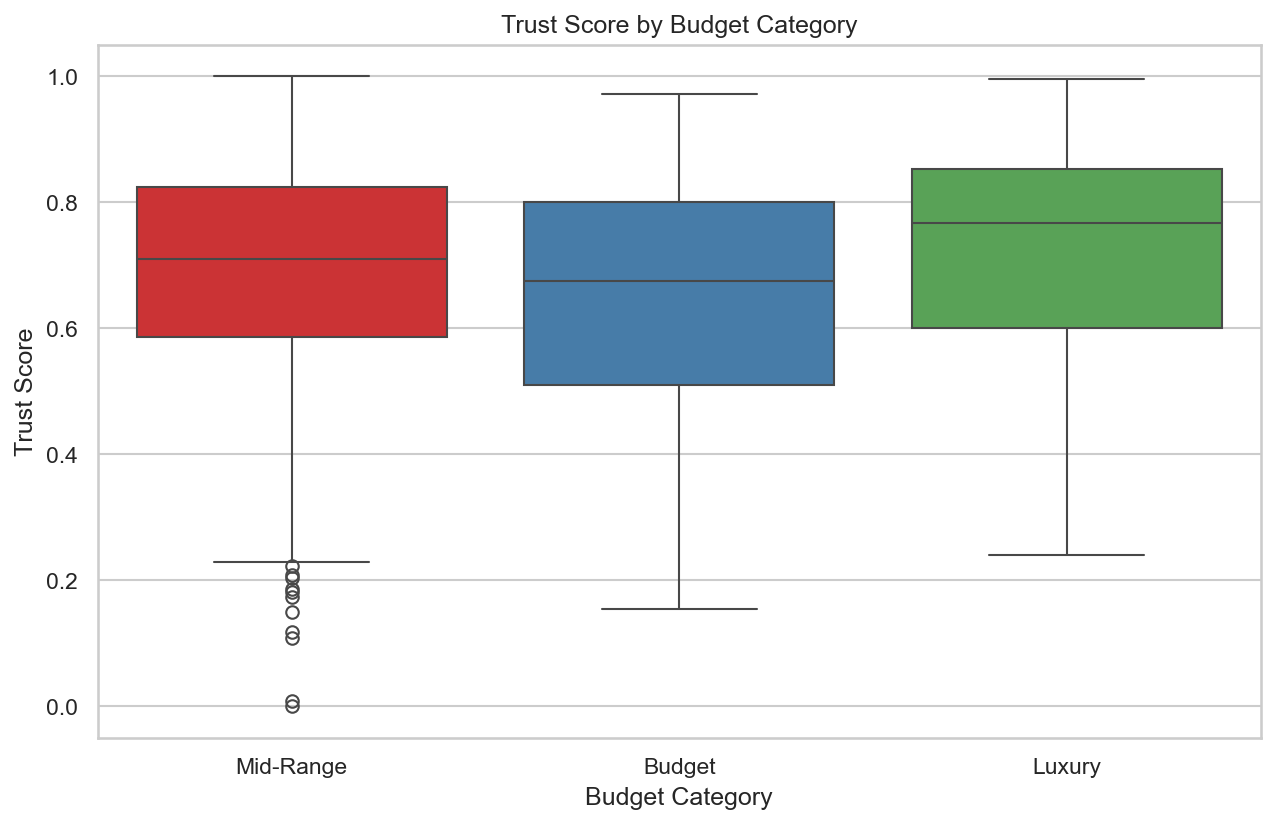

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eng, x='budget_category', y='trust_score', palette='Set1')
plt.title('Trust Score by Budget Category')
plt.xlabel('Budget Category')
plt.ylabel('Trust Score')
plt.savefig(os.path.join(FIG_DIR, '05_trust_by_budget.png'))
plt.show()

**Interpretation & Key Insight:**
> The box plot shows that 'Luxury' budget hotels have a slightly higher median trust score with a narrower distribution. 'Budget' hotels have lower median trust scores and higher variance, confirming that cheaper hotels exhibit higher risk of quality variance.

## 4. Correlation Analysis
Analyzing correlation of engineered features.

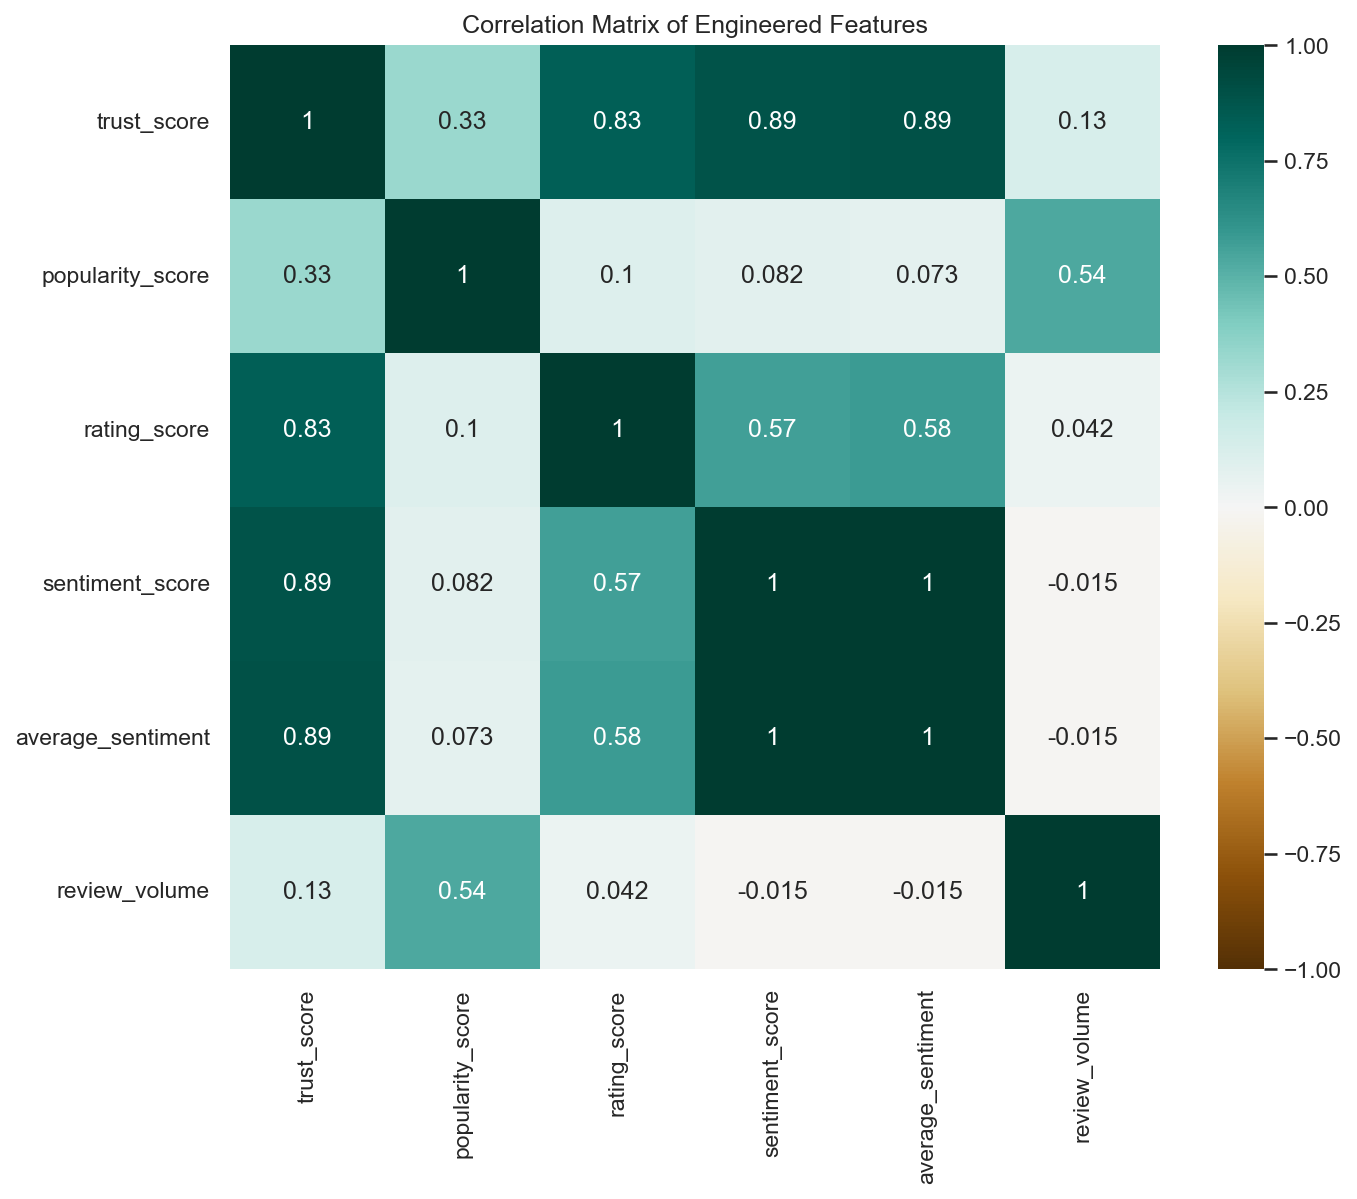

In [5]:
score_cols = ['trust_score', 'popularity_score', 'rating_score', 'sentiment_score', 'average_sentiment', 'review_volume']
corr_mat = df_eng[score_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, cmap='BrBG', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Engineered Features')
plt.savefig(os.path.join(FIG_DIR, '05_engineered_correlations.png'))
plt.show()

**Interpretation & Key Insight:**
> `trust_score` correlates strongly with `average_sentiment` (0.83) and `rating_score` (0.75), which is expected since trust is derived from ratings and sentiments. `popularity_score` has a low correlation with trust score, validating that popularity and trust are independent metrics.